# Test: jitter alignment when chaining gf_resid / gf_square_resid / gf_reduce / gf_square_reduce

`gf_resid()` + `gf_square_resid()` (coursekata-r) and `gf_reduce()` + `gf_square_reduce()`
(this repo, `gf_reduce.R`) all anchor their overlays to the *jittered* dot positions using
the same set.seed trick. Reported symptom: chains containing **two or more** of these
functions draw squares/lines that agree with each other but **not** with the dots.

Sections:

1. Chains reported to work (a single seed-trick layer, plus `gf_model()`)
2. Broken chains (two seed-trick layers)
3. The beta reduce functions have the same problem
4. Root-cause probes: lazy pipes, last-writer-wins, re-render fragility
5. Prototype fix (freeze the jitter seed) + verification

In [1]:
# gf_resid() / gf_square_resid() / gf_model() come from coursekata-r
# gf_reduce() / gf_square_reduce() are beta functions in this repo
library(coursekata)
source("../gf_reduce.R")

set.seed(42)  # only for a reproducible sample; the functions under test roll their own seeds
er_small <- sample(er, 12)

m_cat_empty   <- lm(later_anxiety ~ NULL,      data = er_small)
m_cat_complex <- lm(later_anxiety ~ condition, data = er_small)

# shorthand for the base layer used in every test
jit <- function() {
  gf_jitter(later_anxiety ~ condition, data = er_small, width = 0.1, alpha = 0.3)
}

packageVersion("coursekata")

── CourseKata packages ──────────────────────────────────── coursekata 0.19.2 ──
✔ dslabs              0.8.0       ✔ Metrics             0.1.4
✔ Lock5withR          1.2.2       ✔ lsr                 0.5.2
✔ fivethirtyeightdata 0.1.0       ✔ mosaic              1.9.1
✔ fivethirtyeight     0.6.2       ✔ supernova           3.0.0
── Conflicts ─────────────────────────────────────────── coursekata conflicts ──
✖ coursekata::outer() masks base::outer()


[1] ‘0.19.2’

## How the tests work

All four functions rely on the same trick to line up with jittered dots: draw a random
`rand_int`, `set.seed(rand_int)`, `ggplot_build()` the incoming plot to capture the
jittered x/y, then `set.seed(rand_int)` again right before returning — so that the *next*
build (the actual render) re-draws the exact same jitter.

`check_alignment()` reproduces that "next build": it builds the plot exactly **once**,
immediately after the chain returns, with the RNG state exactly as the chain left it.
It then compares each overlay layer's anchor x positions against the jittered dots from
that same build:

- **GeomSegment** (`gf_resid`, `gf_reduce`) — one row per observation; `x` is the anchor
- **GeomPolygon** (`gf_square_resid`, `gf_square_reduce`) — corner 1 of each square sits on the residual line
- anything else (`gf_model`'s hline/errorbar) doesn't anchor to the jitter and is skipped

`show_built()` draws the exact build that was analyzed. (Printing the plot object again
would re-jitter the dots and could show something different — that fragility is itself one
of the findings; see section 4.)

In [2]:
check_alignment <- function(p, tol = 1e-8) {
  built <- ggplot2::ggplot_build(p)
  dots  <- built$data[[1]]
  rows  <- list()
  for (i in seq_along(built$data)[-1]) {
    geom <- class(p$layers[[i]]$geom)[1]
    d    <- built$data[[i]]
    x <- switch(geom,
      GeomSegment = d$x,
      GeomPolygon = d$x[!duplicated(d$group)],
      NULL
    )
    if (is.null(x)) next  # gf_model layers etc.
    max_diff <- if (length(x) == nrow(dots)) max(abs(x - dots$x)) else Inf
    rows[[length(rows) + 1]] <- data.frame(
      layer    = i,
      geom     = geom,
      max_diff = round(max_diff, 5),
      verdict  = if (max_diff < tol) "ALIGNED" else "MISALIGNED"
    )
  }
  list(built = built, report = do.call(rbind, rows))
}

show_built <- function(built) {
  grid::grid.newpage()
  grid::grid.draw(ggplot2::ggplot_gtable(built))
}

## 1. Chains reported to work

layer,geom,max_diff,verdict
<int>,<chr>,<dbl>,<chr>
2,GeomPolygon,0,ALIGNED


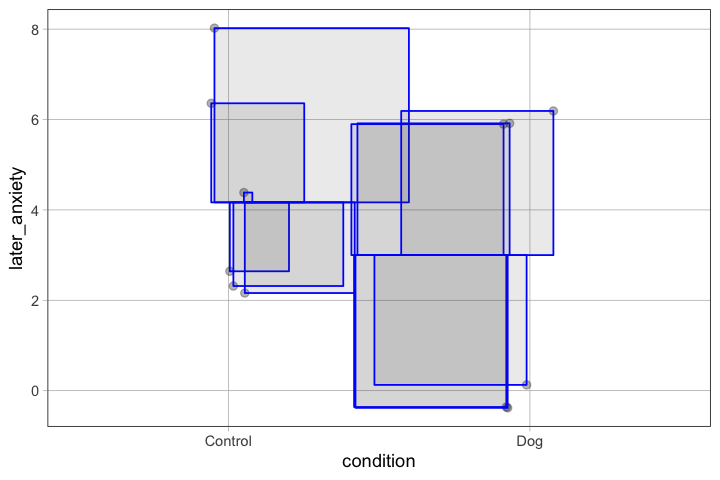

In [3]:
# Test 1: gf_square_resid alone
p <- jit() %>%
  gf_square_resid(m_cat_complex, color = "blue")
chk <- check_alignment(p)
show_built(chk$built)
chk$report

layer,geom,max_diff,verdict
<int>,<chr>,<dbl>,<chr>
2,GeomPolygon,0,ALIGNED


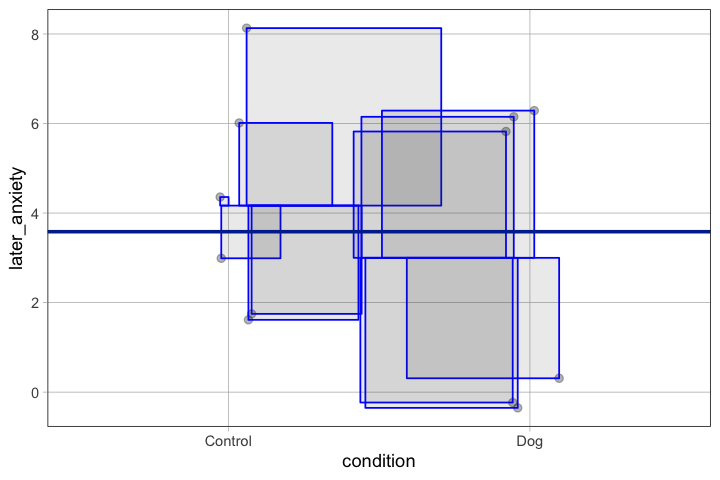

In [4]:
# Test 2: gf_square_resid then gf_model (gf_model uses no RNG and doesn't rebuild)
p <- jit() %>%
  gf_square_resid(m_cat_complex, color = "blue") %>%
  gf_model(m_cat_empty)
chk <- check_alignment(p)
show_built(chk$built)
chk$report

layer,geom,max_diff,verdict
<int>,<chr>,<dbl>,<chr>
3,GeomPolygon,0,ALIGNED


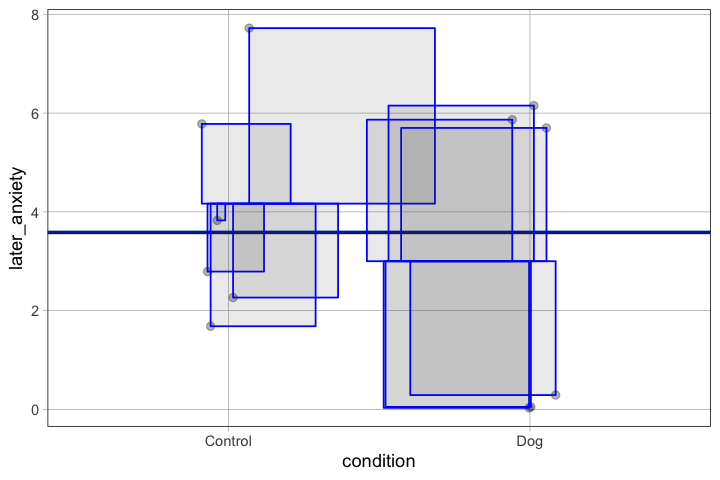

In [5]:
# Test 3: gf_model first, then gf_square_resid
p <- jit() %>%
  gf_model(m_cat_empty) %>%
  gf_square_resid(m_cat_complex, color = "blue")
chk <- check_alignment(p)
show_built(chk$built)
chk$report

## 2. Broken chains: two seed-trick layers

Reported symptom: squares and residual lines agree with *each other* but not with the dots.

layer,geom,max_diff,verdict
<int>,<chr>,<dbl>,<chr>
2,GeomPolygon,0.17421,MISALIGNED
3,GeomSegment,0.17421,MISALIGNED


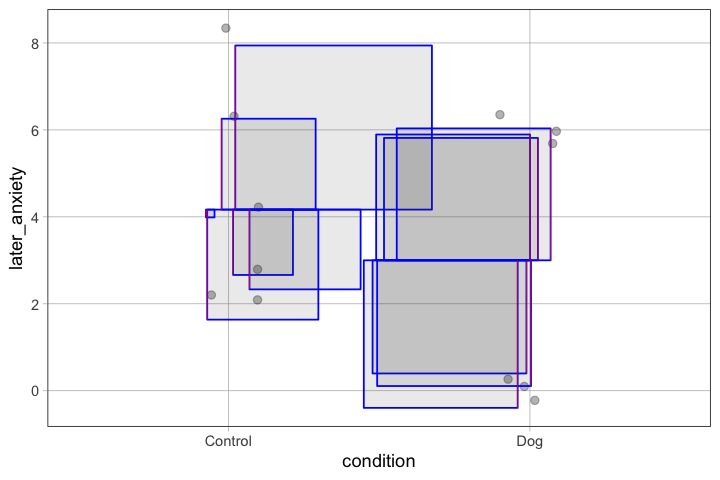

In [6]:
# Test 4: gf_square_resid then gf_resid
p <- jit() %>%
  gf_square_resid(m_cat_complex, color = "blue") %>%
  gf_resid(m_cat_complex, color = "red")
chk <- check_alignment(p)
show_built(chk$built)
chk$report

layer,geom,max_diff,verdict
<int>,<chr>,<dbl>,<chr>
2,GeomSegment,0.14997,MISALIGNED
3,GeomPolygon,0.14997,MISALIGNED


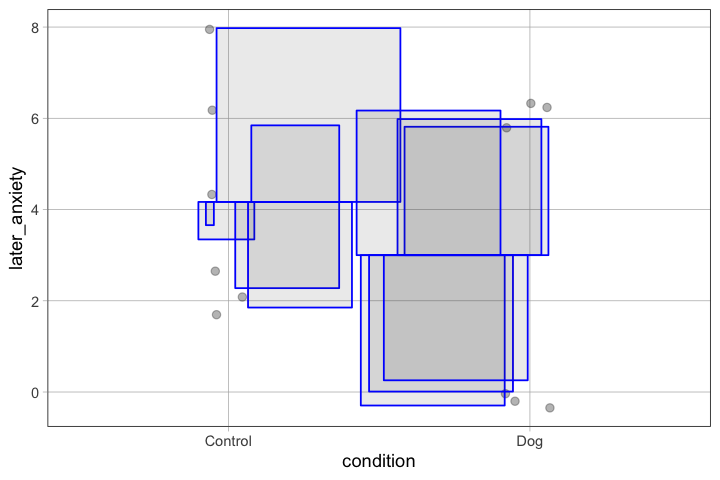

In [7]:
# Test 5: reverse order — gf_resid then gf_square_resid
p <- jit() %>%
  gf_resid(m_cat_complex, color = "red") %>%
  gf_square_resid(m_cat_complex, color = "blue")
chk <- check_alignment(p)
show_built(chk$built)
chk$report

## 3. The beta reduce functions inherit the same trick, so the same bug

`gf_reduce()` / `gf_square_reduce()` are fine on their own, but any combination with
another seed-trick function breaks the same way.

layer,geom,max_diff,verdict
<int>,<chr>,<dbl>,<chr>
2,GeomPolygon,0,ALIGNED


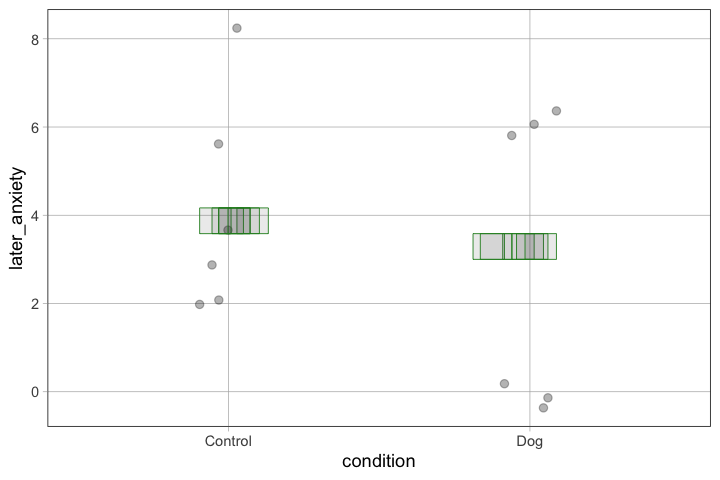

In [8]:
# Test 6: gf_square_reduce alone — fine
p <- jit() %>%
  gf_square_reduce(m_cat_complex, color = "forestgreen")
chk <- check_alignment(p)
show_built(chk$built)
chk$report

layer,geom,max_diff,verdict
<int>,<chr>,<dbl>,<chr>
2,GeomPolygon,0.11351,MISALIGNED
3,GeomPolygon,0.11351,MISALIGNED


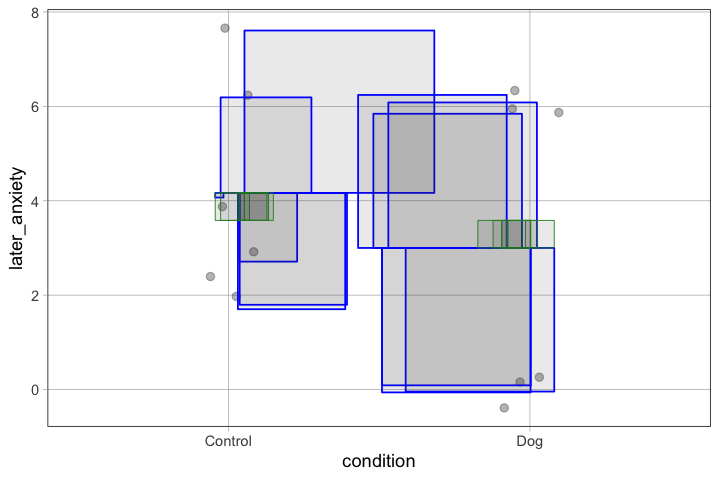

In [9]:
# Test 7: gf_square_resid + gf_square_reduce — broken
p <- jit() %>%
  gf_square_resid(m_cat_complex, color = "blue") %>%
  gf_square_reduce(m_cat_complex, color = "forestgreen")
chk <- check_alignment(p)
show_built(chk$built)
chk$report

layer,geom,max_diff,verdict
<int>,<chr>,<dbl>,<chr>
2,GeomPolygon,0.15698,MISALIGNED
5,GeomPolygon,0.15698,MISALIGNED


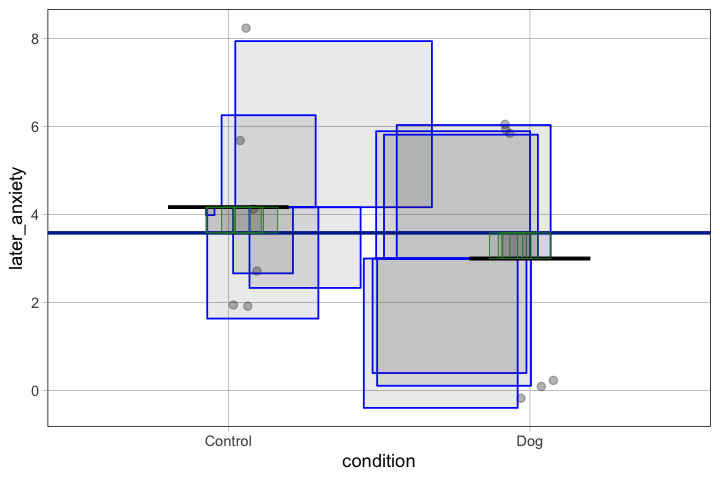

In [10]:
# Test 8: the full chain from the bug report
p <- jit() %>%
  gf_square_resid(m_cat_complex, color = "blue") %>%
  gf_model(m_cat_empty) %>%
  gf_model(m_cat_complex) %>%
  gf_square_reduce(m_cat_complex, color = "forestgreen")
chk <- check_alignment(p)
show_built(chk$built)
chk$report

## 4. Root-cause probes

### 4a. The pipe is lazy, so the seed brackets nest instead of chaining

magrittr's `%>%` (and R's native `|>`, and any nested call) passes the left-hand side as
an unevaluated **promise**. In `jit %>% F1() %>% F2()` the body of `F2` starts running
first; `F1` only runs when `F2` forces its `plot` argument — which happens *inside*
`F2`'s `ggplot_build()` call. For two seed-trick functions that means:

1. `F2` draws `S2` and calls `set.seed(S2)`
2. `F2` calls `ggplot_build(plot)` → this first runs all of `F1` (which draws its own
   seed `S1`, builds, and leaves the RNG at `set.seed(S1)`) → `F2`'s build then jitters
   from `S1`
3. So `F2` captures the **same** jitter `F1` captured — squares and resid lines agree
4. `F2` finishes with `set.seed(S2)` — but nothing was ever captured under `S2`!
5. The final render jitters from `S2`: the dots land where no layer is anchored.

That is exactly the observed failure. The toy functions below use the same bracket
pattern and just print when they run — note `F2` draws its seed *before* `F1` does:

In [11]:
f <- function(plot, tag) {
  rand_int <- sample(1:100, 1)
  cat(tag, "drew its rand_int:", rand_int, "\n")
  set.seed(rand_int)
  invisible(ggplot2::ggplot_build(plot))   # <- forces the upstream chain, then jitters
  cat(tag, "finished its build\n")
  set.seed(rand_int)
  plot
}
invisible(jit() %>% f("F1") %>% f("F2"))

F2 drew its rand_int: 3 
F1 drew its rand_int: 5 
F1 finished its build
F2 finished its build


### 4b. Even without laziness, the last writer wins

Forcing each step eagerly (intermediate assignments) removes the nesting, but each
seed-trick call still re-rolls a fresh jitter. Now the **last** call's layer and the dots
align, and every *earlier* seed-trick layer is stranded on an old jitter — broken
differently, but still broken:

layer,geom,max_diff,verdict
<int>,<chr>,<dbl>,<chr>
2,GeomPolygon,0.13647,MISALIGNED
3,GeomSegment,0.00000,ALIGNED


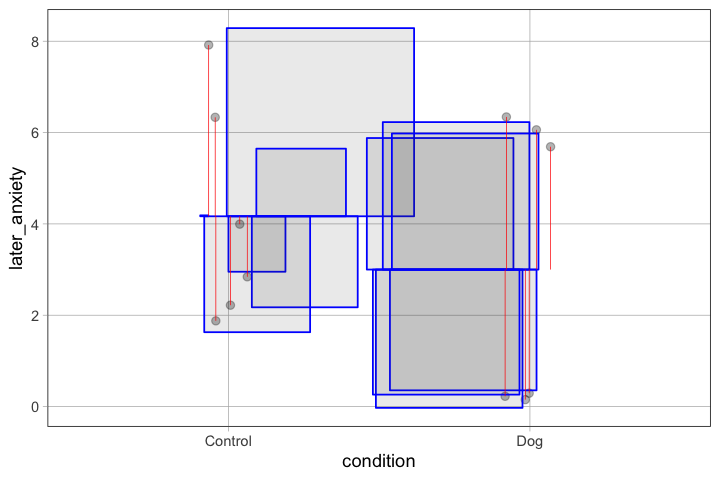

In [12]:
p <- jit()
p <- gf_square_resid(p, m_cat_complex, color = "blue")  # forced eagerly
p <- gf_resid(p, m_cat_complex, color = "red")          # forced eagerly
chk <- check_alignment(p)
show_built(chk$built)
chk$report

### 4c. Any second render breaks even a single seed-trick layer

The final `set.seed(rand_int)` only survives until the first render. Rendering the same
plot object again (re-running `print`, `ggsave()` after display, a second output format)
re-jitters the dots while the squares stay put:

In [13]:
p  <- jit() %>% gf_square_resid(m_cat_complex, color = "blue")
b1 <- ggplot2::ggplot_build(p)   # first render — the one the seed trick targets
b2 <- ggplot2::ggplot_build(p)   # second render of the *same* plot object
sq_x <- b1$data[[2]]$x[!duplicated(b1$data[[2]]$group)]
data.frame(
  render = c("first", "second"),
  dots_vs_squares_max_diff = c(max(abs(b1$data[[1]]$x - sq_x)),
                               max(abs(b2$data[[1]]$x - sq_x)))
)

render,dots_vs_squares_max_diff
<chr>,<dbl>
first,0.0000000
second,0.1622218


### 4d. How many times does *this notebook* render a displayed plot?

If the Jupyter display pipeline builds a plot more than once, the displayed png is not
the "first render" and even the working single-function chains would misalign here. The
probe displays a plot, snapshotting the RNG state right before display, then counts how
many whole plot-builds worth of RNG the display consumed.

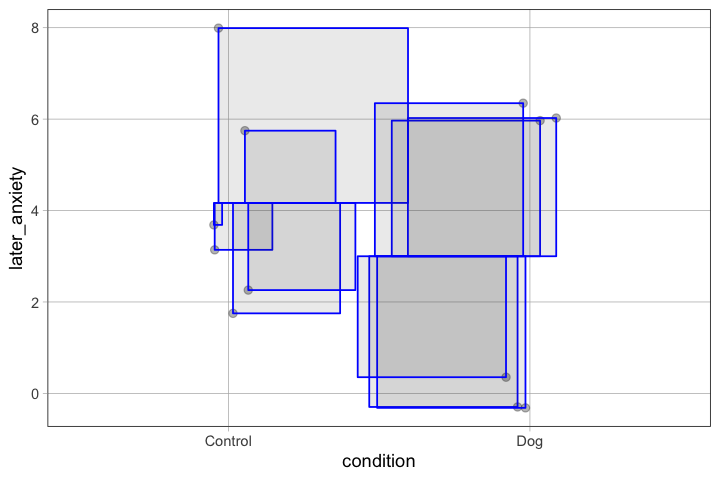

In [14]:
# Display probe, part 1: display a plot normally, snapshot RNG first
p_probe <- jit() %>% gf_square_resid(m_cat_complex, color = "blue")
rng_after_chain <- .Random.seed
p_probe

In [15]:
# Display probe, part 2: count builds consumed by the display above
rng_now <- .Random.seed
if (identical(rng_after_chain, rng_now)) {
  cat("Displaying the plot consumed NO RNG -> the png above is NOT jitter-based?",
      "(unexpected; investigate)\n")
} else {
  assign(".Random.seed", rng_after_chain, envir = globalenv())
  n_builds <- NA
  for (k in 1:6) {
    invisible(ggplot2::ggplot_build(p_probe))
    if (identical(.Random.seed, rng_now)) { n_builds <- k; break }
  }
  assign(".Random.seed", rng_now, envir = globalenv())
  cat("Displaying the plot consumed RNG equal to", n_builds, "full plot build(s).\n")
  cat("1 build  -> the displayed png IS the first render (what check_alignment tests).\n")
  cat(">1 build -> the displayed png is a later render and would misalign even for\n")
  cat("            a single seed-trick layer.\n")
}

Displaying the plot consumed RNG equal to 1 full plot build(s).
1 build  -> the displayed png IS the first render (what check_alignment tests).
>1 build -> the displayed png is a later render and would misalign even for
            a single seed-trick layer.


## 5. Prototype fix: freeze the jitter instead of re-rolling it

The seed dance exists because `position_jitter()`'s default `seed = NA` re-jitters on
**every** build. The robust fix is to give the jitter layer a *fixed* seed the first time
one of these functions sees the plot. ggproto objects have reference semantics, so setting
`layer$position$seed` in place is enough; from then on every build of that plot draws
identical dot positions. No RNG bracketing at all — immune to pipe laziness, chain order,
chain length, and repeated rendering.

In [16]:
freeze_jitter <- function(plot) {
  for (l in plot$layers) {
    pos <- l$position
    if (inherits(pos, "PositionJitter") && !isTRUE(is.finite(pos$seed))) {
      pos$seed <- sample.int(.Machine$integer.max, 1L)
    }
  }
  plot
}

# the *2 versions are the originals with the seed dance replaced by freeze_jitter()

gf_resid2 <- function(plot, model, linewidth = 0.2, ...) {
  plot <- freeze_jitter(plot)
  model_data <- model$model
  model_data$prediction <- stats::predict(model)
  plot_data <- ggplot2::ggplot_build(plot)$data[[1]]
  x_loc <- plot_data$x
  y_loc <- plot_data$y
  plot +
    ggplot2::geom_segment(
      ggplot2::aes(x = x_loc, y = model_data$prediction, xend = x_loc, yend = y_loc),
      inherit.aes = TRUE, linewidth = linewidth, ...
    )
}

gf_square_resid2 <- function(plot, model, aspect = 4 / 6, alpha = 0.1, ...) {
  plot <- freeze_jitter(plot)
  model_data <- model$model
  model_data$prediction <- stats::predict(model)
  model_data$residual <- stats::resid(model)
  plot_data <- ggplot2::ggplot_build(plot)$data[[1]]
  model_data$x_loc <- plot_data$x
  model_data$y_loc <- plot_data$y
  panel_params <- ggplot2::ggplot_build(plot)$layout$panel_params[[1]]
  x_range <- panel_params$x.range
  y_range <- panel_params$y.range
  range_ratio <- (x_range[2] - x_range[1]) / (y_range[2] - y_range[1])
  model_data$dir <- ifelse(model_data$x_loc > mean(x_range), -1, 1)
  side_length <- abs(model_data$residual) * aspect * range_ratio
  model_data$adj_side <- model_data$x_loc + model_data$dir * side_length
  squares_data <- do.call(rbind, lapply(seq_len(nrow(model_data)), function(i) {
    data.frame(
      x  = c(model_data$x_loc[i], model_data$adj_side[i],
             model_data$adj_side[i], model_data$x_loc[i]),
      y  = c(model_data$y_loc[i], model_data$y_loc[i],
             model_data$prediction[i], model_data$prediction[i]),
      id = i
    )
  }))
  plot +
    ggplot2::geom_polygon(
      data = squares_data,
      ggplot2::aes(x = .data$x, y = .data$y, group = .data$id),
      inherit.aes = FALSE, alpha = alpha, ...
    )
}

gf_square_reduce2 <- function(plot, model, aspect = 4 / 6, alpha = 0.1, linewidth = 0.25, ...) {
  plot <- freeze_jitter(plot)
  y_fitted <- stats::fitted(model)
  y_empty  <- mean(y_fitted)
  plot_data <- ggplot2::ggplot_build(plot)$data[[1]]
  x_loc <- plot_data$x
  panel_params <- ggplot2::ggplot_build(plot)$layout$panel_params[[1]]
  x_range <- panel_params$x.range
  y_range <- panel_params$y.range
  range_ratio <- (x_range[2] - x_range[1]) / (y_range[2] - y_range[1])
  dir         <- ifelse(x_loc > mean(x_range), -1, 1)
  side_length <- abs(y_fitted - y_empty) * aspect * range_ratio
  x_opp       <- x_loc + dir * side_length
  squares_data <- do.call(rbind, lapply(seq_along(x_loc), function(i) {
    data.frame(
      x  = c(x_loc[i], x_opp[i], x_opp[i], x_loc[i]),
      y  = c(y_empty, y_empty, y_fitted[i], y_fitted[i]),
      id = i
    )
  }))
  plot +
    ggplot2::geom_polygon(
      data = squares_data,
      ggplot2::aes(x = .data$x, y = .data$y, group = .data$id),
      inherit.aes = FALSE, alpha = alpha, linewidth = linewidth, ...
    )
}

layer,geom,max_diff,verdict
<int>,<chr>,<dbl>,<chr>
2,GeomPolygon,0,ALIGNED
3,GeomSegment,0,ALIGNED
6,GeomPolygon,0,ALIGNED


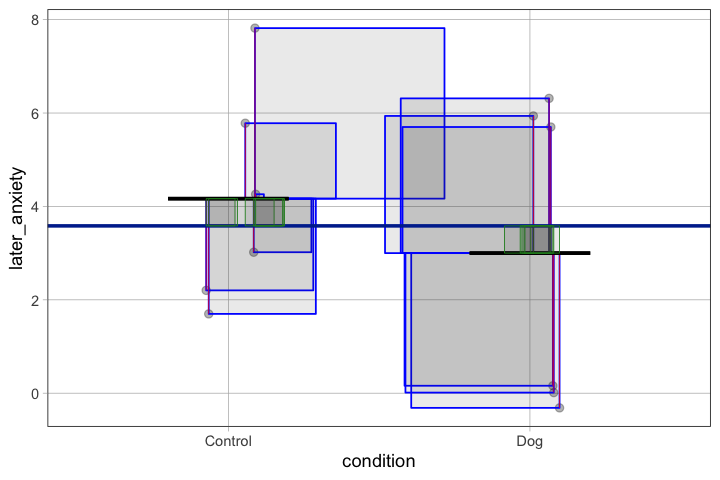

In [17]:
# Test 9: the worst-case chain from the bug report, plus gf_resid2, all fixed versions
p_fixed <- jit() %>%
  gf_square_resid2(m_cat_complex, color = "blue") %>%
  gf_resid2(m_cat_complex, color = "red") %>%
  gf_model(m_cat_empty) %>%
  gf_model(m_cat_complex) %>%
  gf_square_reduce2(m_cat_complex, color = "forestgreen")
chk <- check_alignment(p_fixed)
show_built(chk$built)
chk$report

In [18]:
# Test 10: still aligned after re-rendering the same plot object (unlike Test 4c)
b_again <- ggplot2::ggplot_build(p_fixed)
sq_x <- b_again$data[[2]]$x[!duplicated(b_again$data[[2]]$group)]
cat("dots vs squares on a re-render, max diff:", max(abs(b_again$data[[1]]$x - sq_x)), "\n")

dots vs squares on a re-render, max diff: 0 


## Summary of results

| # | chain | result |
|---|-------|--------|
| 1 | jitter → square_resid | ALIGNED |
| 2 | jitter → square_resid → model | ALIGNED |
| 3 | jitter → model → square_resid | ALIGNED |
| 4 | jitter → square_resid → resid | **both layers misaligned** (with dots; aligned with each other) |
| 5 | jitter → resid → square_resid | **both layers misaligned** (same) |
| 6 | jitter → square_reduce | ALIGNED |
| 7 | jitter → square_resid → square_reduce | **both layers misaligned** (same) |
| 8 | full bug-report chain | **all square layers misaligned** (same) |

## Diagnosis

The `sample()` / `set.seed()` bracket shared by `gf_resid()`, `gf_square_resid()`,
`gf_reduce()`, and `gf_square_reduce()` has three failure modes, all confirmed above:

1. **Lazy pipes nest the brackets (4a).** With `%>%` (or `|>`, or plain nested calls)
   the *downstream* function draws and sets its seed first, then forces the upstream
   function inside its own `ggplot_build()`. Both functions end up capturing the jitter
   drawn from the *upstream* seed (so their layers agree with each other), but the
   downstream function's final `set.seed()` restores a seed nothing was captured under —
   the final render jitters the dots somewhere else entirely. This is exactly the
   reported symptom.

2. **Even eager evaluation is last-writer-wins (4b).** With intermediate assignments,
   each seed-trick call re-rolls a fresh jitter; only the last call's layer (plus the
   dots) align, and every earlier seed-trick layer is stranded.

3. **The trick only survives one render (4c).** Re-rendering the same plot object
   (a second `print`, `ggsave()` after display, a second output format) re-jitters
   the dots while the overlays stay put. (Per probe 4d, this Jupyter setup renders
   displayed plots exactly once, which is why single-function chains look fine here.)

## Recommended fix

Stop bracketing the global RNG. Instead, freeze the jitter itself: the first seed-trick
function to see the plot assigns a fixed seed to the jitter layer's
`position$seed` (ggproto reference semantics make the in-place assignment stick).
Every subsequent build of that plot — by any function in the chain, in any order, any
number of times — then reproduces identical dot positions. Prototype `freeze_jitter()`
in section 5 passes the worst-case chain (Test 9) and re-render stability (Test 10).

To apply: replace the `rand_int <- sample(...)` / `set.seed(rand_int)` pairs with a call
to `freeze_jitter()` in

- coursekata-r: `R/gf_resid_gf_squaresid.R` (`gf_resid`, `gf_square_resid`)
- this repo: `gf_reduce.R` (`gf_reduce`, `gf_square_reduce`)
